In [1]:
words = open("names.txt", 'r').read().splitlines()

In [2]:
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
letters = sorted(list(set("".join(word for word in words))))

In [4]:
itos = {i+1:s for i,s in enumerate(letters)}
itos[0] = '.'
stoi = {s:i for i,s in itos.items()}

In [5]:
import torch
import torch.nn.functional as F

In [6]:
one_hot = F.one_hot(torch.tensor(25), 27)
one_hot

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0])

# create dataset

In [7]:
def strToVec(s):
    idxs = torch.tensor([stoi[c] for c in s])
    one_hot = F.one_hot(idxs, 27).float()
    return one_hot.flatten()

In [20]:
def build_dataset(words, n_gram):

    xs = []
    ys = []
    
    for word in words:
        word_padded = '.'*(n_gram-1) + word + '.'
        for i in range(len(word_padded)- n_gram+1):
            xs_letters = word_padded[i:i+n_gram-1]
            ys_letter = word_padded[i+n_gram-1]
            xs_vec = strToVec(xs_letters)
            ys_vec = strToVec(ys_letter)
            xs.append(xs_vec)
            ys.append(ys_vec)
    xs = torch.stack(xs)
    ys = torch.stack(ys)
    return xs, ys

In [21]:
import random
random.shuffle(words)

n_gram = 3

x_tr,y_tr = build_dataset(words[:int(0.8*len(words))], n_gram)
x_dev,y_dev = build_dataset(words[int(0.8*len(words)):int(0.9*len(words))], n_gram)
x_test, y_test = build_dataset(words[int(0.9*len(words)):], n_gram)

In [22]:
x_tr.size(), y_tr.size() # (num_examples, vocab size)

(torch.Size([182592, 54]), torch.Size([182592, 27]))

# Neural Network

In [23]:
n_nodes = 100
n_letters = len(itos)

In [24]:
w1 = torch.randn(((n_gram-1)*n_letters, n_nodes)) / (n_gram-1)**0.5; w1.requires_grad = True
b1 = torch.randn(n_nodes) * 0    ; b1.requires_grad = True
w2 = torch.randn((n_nodes, n_letters)) * 0.01 ; w2.requires_grad = True
b2 = torch.randn(n_letters) * 0       ; b2.requires_grad = True 
parameters = [w1, b1, w2, b2]

In [25]:
w1.size()

torch.Size([54, 100])

In [26]:
def eval(xs, ys):
    h = torch.tanh(xs @ w1 + b1)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, ys)
    return loss.item()

In [27]:
lossi = []
for i in range(1000):
    # forward pass
    h = torch.tanh(x_tr @ w1 + b1)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y_tr)

    # backwards pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad
    lossi.append(loss.item())

    

In [28]:
lossi

[3.2943546772003174,
 3.267209768295288,
 3.241083860397339,
 3.21597957611084,
 3.1918978691101074,
 3.1688313484191895,
 3.1467673778533936,
 3.125684976577759,
 3.1055564880371094,
 3.08634614944458,
 3.06801438331604,
 3.050515651702881,
 3.0338048934936523,
 3.017834186553955,
 3.002558946609497,
 2.9879353046417236,
 2.973921775817871,
 2.9604809284210205,
 2.9475784301757812,
 2.9351847171783447,
 2.9232709407806396,
 2.9118123054504395,
 2.9007863998413086,
 2.890171766281128,
 2.8799502849578857,
 2.870103120803833,
 2.860614776611328,
 2.851469039916992,
 2.842651128768921,
 2.8341472148895264,
 2.8259432315826416,
 2.818025588989258,
 2.81038236618042,
 2.803001642227173,
 2.795870780944824,
 2.7889792919158936,
 2.7823164463043213,
 2.775871515274048,
 2.7696352005004883,
 2.7635974884033203,
 2.7577502727508545,
 2.752084255218506,
 2.746591806411743,
 2.741264581680298,
 2.736096143722534,
 2.731078624725342,
 2.7262067794799805,
 2.721472978591919,
 2.716871738433838,
 2

In [29]:
import matplotlib.pyplot as plt

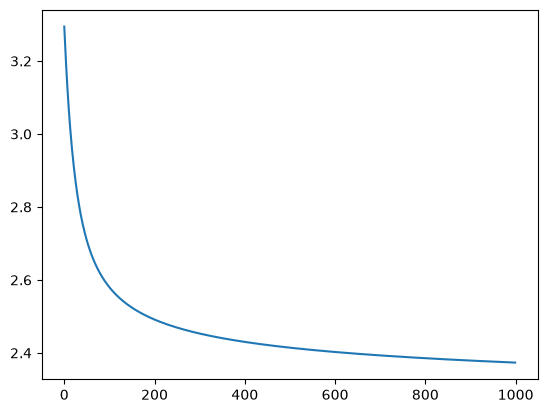

In [30]:
plt.plot(lossi)

In [31]:
eval(x_dev,y_dev)

2.3753528594970703

In [32]:
# sample from model
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    idxs = [0 for i in range(n_gram-1)]
    while True:
        #print(itos[idxs[0]], itos[idxs[1]])
        x_enc = F.one_hot(torch.tensor(idxs), 27).float()
        x_enc = x_enc.flatten()
        h = torch.tanh(x_enc @ w1 + b1)
        logits = h @ w2 + b2
        p = torch.softmax(logits, dim=0)
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        #print(itos[ix])
        out.append(itos[ix])

        for i in range(n_gram-2):
            idxs[i] = idxs[i+1]
        idxs[-1] = ix

        if ix == 0:
            break
    print(''.join(out))

cex.
maromakuriilazityharellimittain.
lusan.
ka.
da.
samiyaubjavhrigotai.
morielliau.
ke.
teda.
kaley.
